In [1]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

In [2]:
np.random.seed(42)

In [3]:
# change path to your own path
df = pd.read_csv(r"C:\Users\bjorn\Desktop\Spaghetti\UberPython\XAI\XAI_01\data\diabetes-health-indicators-dataset.zip\diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
X = df.drop("Diabetes_binary", axis=1).values
y = df["Diabetes_binary"].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    enable_categorical=False,
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [15]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [21]:
probabilities = model.predict_proba(X_test)[:, 1]
predictions = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, predictions)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8656


In [26]:
auc = roc_auc_score(y_test, probabilities)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8278


In [27]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[42738   929]
 [ 5889  1180]]


## Explainability with LIME and SHAP

LIME approximates one prediction locally, while SHAP attributes model output to features. For this binary XGBoost classifier, the default TreeExplainer output is the raw margin (log-odds), not a probability.

Explaining test instance 33
Predicted class: Diabetes
Class probabilities: {'No diabetes': np.float32(0.26), 'Diabetes': np.float32(0.74)}


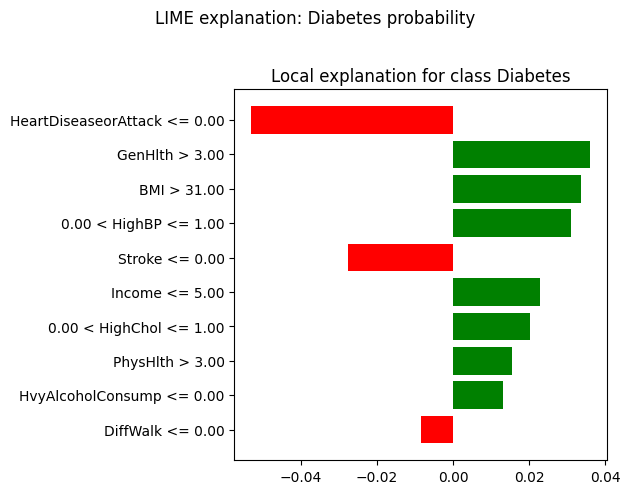

,feature condition,LIME weight
0,HeartDiseaseorAttack <= 0.00,-0.052971
1,GenHlth > 3.00,0.036061
2,BMI > 31.00,0.033665
3,0.00 < HighBP <= 1.00,0.030890
4,Stroke <= 0.00,-0.027665
5,Income <= 5.00,0.022729
6,0.00 < HighChol <= 1.00,0.020336
7,PhysHlth > 3.00,0.015429
8,HvyAlcoholConsump <= 0.00,0.013006
9,DiffWalk <= 0.00,-0.008465


In [22]:
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from collections import Counter
from scipy.stats import spearmanr

feature_names = df.drop(columns="Diabetes_binary").columns.tolist()
class_names = ["No diabetes", "Diabetes"]
pos_label = 1

lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    random_state=42,
)

predicted_classes = model.predict(X_test)
lime_index = int(np.flatnonzero(predicted_classes == pos_label)[0])
lime_instance = X_test[lime_index]
lime_prediction = model.predict_proba(lime_instance.reshape(1, -1))[0]
lime_explanation = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=model.predict_proba,
    num_features=10,
    num_samples=5000,
)

print(f"Explaining test instance {lime_index}")
print(f"Predicted class: {class_names[int(lime_prediction.argmax())]}")
print(f"Class probabilities: {dict(zip(class_names, lime_prediction.round(3)))}")
lime_figure = lime_explanation.as_pyplot_figure(label=pos_label)
lime_figure.suptitle(f"LIME explanation: {class_names[pos_label]} probability", y=1.02)
plt.tight_layout()
plt.show()

lime_weights = pd.DataFrame(
    lime_explanation.as_list(label=pos_label),
    columns=["feature condition", "LIME weight"],
)
lime_weights.reindex(lime_weights["LIME weight"].abs().sort_values(ascending=False).index)

### LIME contrast and stability

Compare a prediction from the other class, then check how consistently LIME selects important features across random seeds.

Contrasting test instance 0
Predicted class: No diabetes
Class probabilities: {'No diabetes': np.float32(0.856), 'Diabetes': np.float32(0.144)}


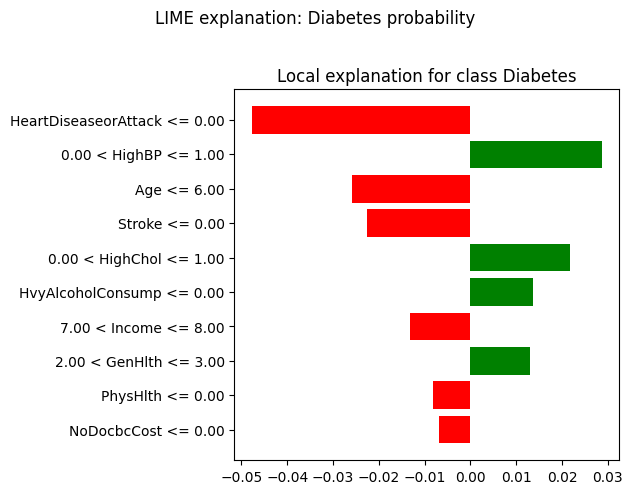

Top feature stability across LIME seeds:
           feature condition  appearances (/10)
HeartDiseaseorAttack <= 0.00                 10
              GenHlth > 3.00                 10
                 BMI > 31.00                 10
       0.00 < HighBP <= 1.00                 10
     0.00 < HighChol <= 1.00                  6
              Income <= 5.00                  4


In [23]:
negative_indices = np.flatnonzero(predicted_classes != pos_label)
contrast_index = int(negative_indices[0])
contrast_instance = X_test[contrast_index]
contrast_prediction = model.predict_proba(contrast_instance.reshape(1, -1))[0]
contrast_explanation = lime_explainer.explain_instance(
    data_row=contrast_instance,
    predict_fn=model.predict_proba,
    num_features=10,
    num_samples=5000,
)

print(f"Contrasting test instance {contrast_index}")
print(f"Predicted class: {class_names[int(contrast_prediction.argmax())]}")
print(f"Class probabilities: {dict(zip(class_names, contrast_prediction.round(3)))}")
contrast_figure = contrast_explanation.as_pyplot_figure(label=pos_label)
contrast_figure.suptitle(f"LIME explanation: {class_names[pos_label]} probability", y=1.02)
plt.tight_layout()
plt.show()

N_RUNS = 10
top_k = 5
feature_counts = Counter()
for seed in range(N_RUNS):
    seeded_explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=class_names,
        mode="classification",
        random_state=seed,
    )
    seeded_explanation = seeded_explainer.explain_instance(
        data_row=lime_instance,
        predict_fn=model.predict_proba,
        labels=(pos_label,),
        num_features=top_k,
        num_samples=5000,
    )
    feature_counts.update(
        feature for feature, _ in seeded_explanation.as_list(label=pos_label)
    )

lime_stability = pd.DataFrame(
    feature_counts.most_common(),
    columns=["feature condition", f"appearances (/{N_RUNS})"],
)
print("Top feature stability across LIME seeds:")
print(lime_stability.to_string(index=False))

### Approximate global importance from LIME

Averaging absolute local weights over test examples gives a rough global ranking; LIME remains a local surrogate method.

             feature  mean |LIME weight|
HeartDiseaseorAttack            0.046883
              HighBP            0.029280
             GenHlth            0.027644
              Stroke            0.025961
            HighChol            0.020553
                 Age            0.018607
                 BMI            0.016880
              Income            0.014167
   HvyAlcoholConsump            0.013325
            DiffWalk            0.009099
            PhysHlth            0.008503
                 Sex            0.005588
         NoDocbcCost            0.004424
           Education            0.004159
              Fruits            0.002516
            MentHlth            0.002447
              Smoker            0.001757
           CholCheck            0.000000
        PhysActivity            0.000000
             Veggies            0.000000
       AnyHealthcare            0.000000


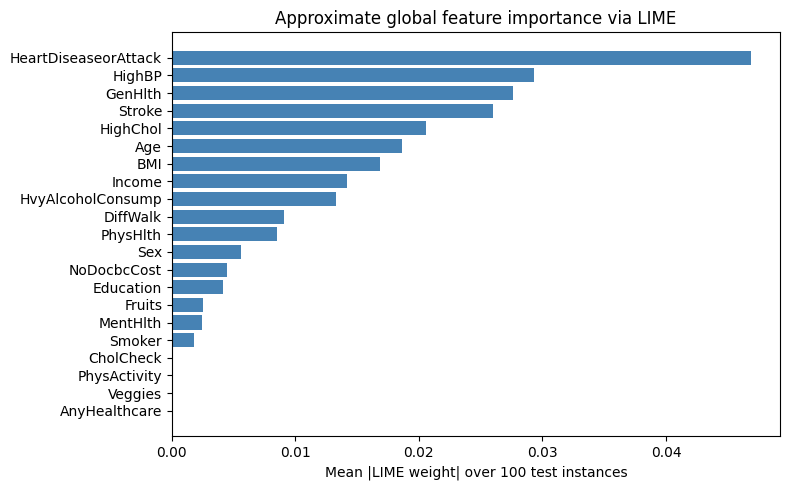

In [24]:
N_EXPLAIN = min(100, len(X_test))
rng = np.random.default_rng(0)
sample_indices = rng.choice(len(X_test), size=N_EXPLAIN, replace=False)
weight_accumulator = {feature: [] for feature in feature_names}

for sample_index in sample_indices:
    local_explanation = lime_explainer.explain_instance(
        data_row=X_test[sample_index],
        predict_fn=model.predict_proba,
        labels=(pos_label,),
        num_features=len(feature_names),
        num_samples=1000,
    )
    for feature_condition, weight in local_explanation.as_list(label=pos_label):
        feature = next(
            (name for name in feature_names if name in feature_condition), None
        )
        if feature is not None:
            weight_accumulator[feature].append(weight)

mean_abs_lime_weight = {
    feature: np.mean(np.abs(weights))
    for feature, weights in weight_accumulator.items()
    if weights
}
lime_global_df = pd.DataFrame(
    sorted(mean_abs_lime_weight.items(), key=lambda item: item[1], reverse=True),
    columns=["feature", "mean |LIME weight|"],
)
print(lime_global_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    lime_global_df["feature"][::-1],
    lime_global_df["mean |LIME weight|"][::-1],
    color="steelblue",
)
ax.set_xlabel(f"Mean |LIME weight| over {N_EXPLAIN} test instances")
ax.set_title("Approximate global feature importance via LIME")
plt.tight_layout()
plt.show()

### SHAP: local and global feature impact

The waterfall explains the same diabetic prediction as LIME, and the beeswarm summarizes feature impact across test examples. SHAP uses probability output here, so its contributions share the same prediction scale as LIME.

Explained 500 test examples; SHAP values shape: (500, 21)
Expected diabetes probability: 0.1433
Diabetes prediction: 74.0%


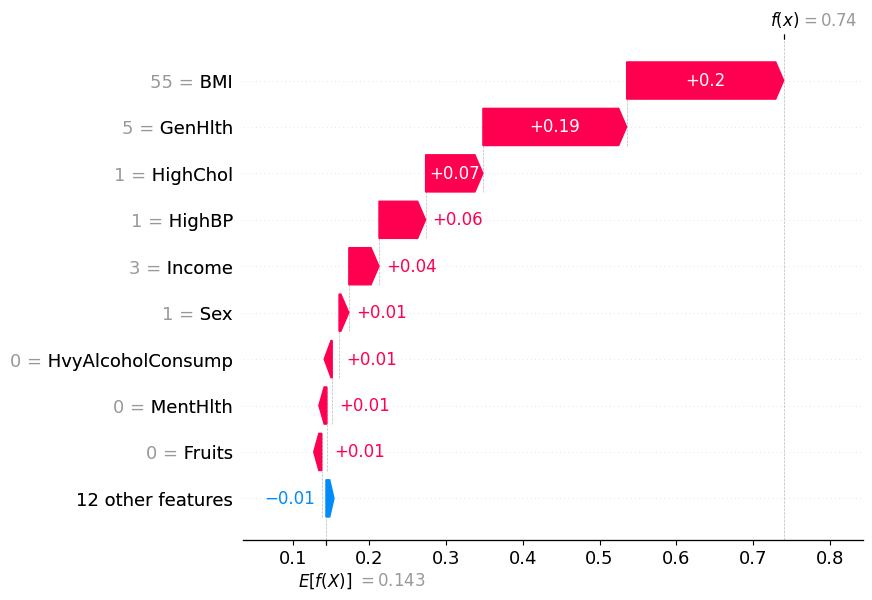

No-diabetes prediction: 85.6%


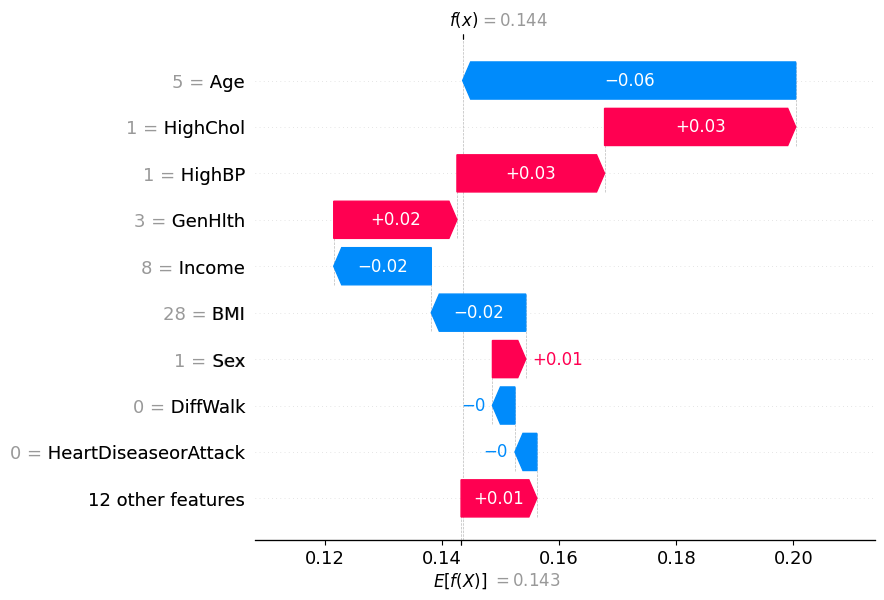

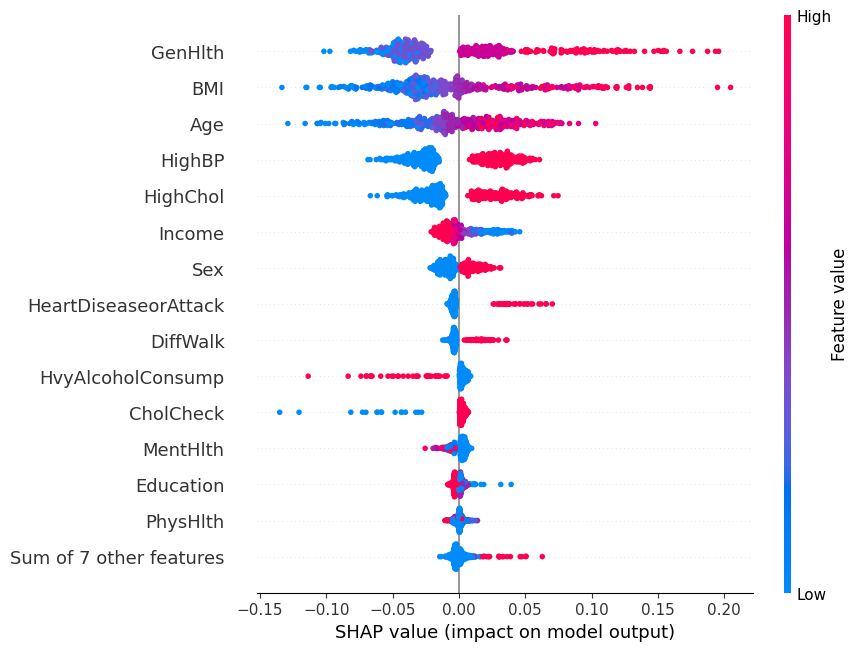

In [28]:
import shap

N_SHAP = min(500, len(X_test))
background_size = min(100, len(X_train))
background_indices = np.random.default_rng(42).choice(
    len(X_train), size=background_size, replace=False
)
X_background = pd.DataFrame(X_train[background_indices], columns=feature_names)
X_shap = pd.DataFrame(X_test[:N_SHAP], columns=feature_names)
shap_explainer = shap.TreeExplainer(
    model,
    data=X_background,
    feature_perturbation="interventional",
    model_output="probability",
)
shap_values = shap_explainer(X_shap)

print(f"Explained {N_SHAP} test examples; SHAP values shape: {shap_values.values.shape}")
print(f"Expected diabetes probability: {float(shap_values.base_values[0]):.4f}")
print(f"Diabetes prediction: {lime_prediction[pos_label]:.1%}")
shap.plots.waterfall(shap_values[lime_index], max_display=10)
print(f"No-diabetes prediction: {contrast_prediction[0]:.1%}")
shap.plots.waterfall(shap_values[contrast_index], max_display=10)
shap.plots.beeswarm(shap_values, max_display=15)

### Global SHAP importance

Mean absolute SHAP values summarize each feature's average contribution magnitude across the explained test sample.

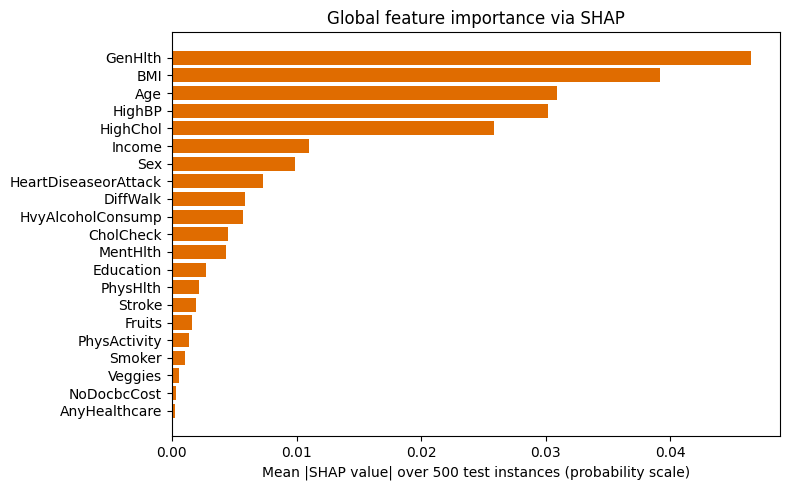

             feature  mean |SHAP|
             GenHlth     0.046462
                 BMI     0.039157
                 Age     0.030864
              HighBP     0.030138
            HighChol     0.025833
              Income     0.011021
                 Sex     0.009913
HeartDiseaseorAttack     0.007351
            DiffWalk     0.005889
   HvyAlcoholConsump     0.005668
           CholCheck     0.004470
            MentHlth     0.004371
           Education     0.002759
            PhysHlth     0.002198
              Stroke     0.001958
              Fruits     0.001634
        PhysActivity     0.001415
              Smoker     0.001028
             Veggies     0.000595
         NoDocbcCost     0.000315
       AnyHealthcare     0.000258


In [29]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_global_df = pd.DataFrame({
    "feature": feature_names,
    "mean |SHAP|": mean_abs_shap,
}).sort_values("mean |SHAP|", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    shap_global_df["feature"][::-1],
    shap_global_df["mean |SHAP|"][::-1],
    color="#e06c00",
)
ax.set_xlabel(f"Mean |SHAP value| over {N_SHAP} test instances (probability scale)")
ax.set_title("Global feature importance via SHAP")
plt.tight_layout()
plt.show()
print(shap_global_df.to_string(index=False))

## LIME and SHAP comparison

Compare local attributions for the same diabetic test instance, then compare the global feature rankings from both methods.

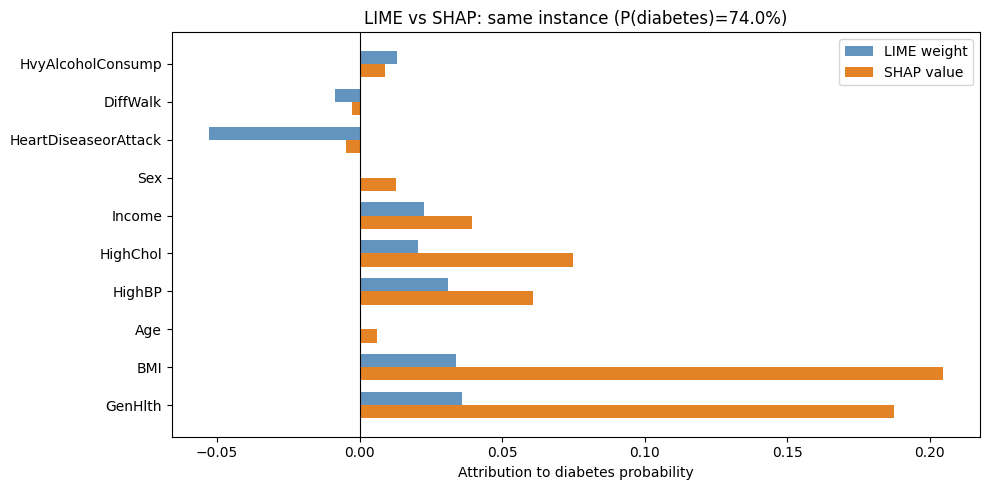

In [30]:
lime_by_feature = {}
for feature_condition, weight in lime_explanation.as_list(label=pos_label):
    feature = next(
        (name for name in feature_names if name in feature_condition), None
    )
    if feature is not None:
        lime_by_feature[feature] = weight

shap_by_feature = dict(zip(feature_names, shap_values.values[lime_index]))
top_features = shap_global_df["feature"].head(10).tolist()
lime_local = [lime_by_feature.get(feature, 0.0) for feature in top_features]
shap_local = [shap_by_feature[feature] for feature in top_features]

positions = np.arange(len(top_features))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    positions + bar_width / 2,
    lime_local,
    bar_width,
    label="LIME weight",
    color="steelblue",
    alpha=0.85,
)
ax.barh(
    positions - bar_width / 2,
    shap_local,
    bar_width,
    label="SHAP value",
    color="#e06c00",
    alpha=0.85,
)
ax.set_yticks(positions)
ax.set_yticklabels(top_features)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Attribution to diabetes probability")
ax.set_title(f"LIME vs SHAP: same instance (P(diabetes)={lime_prediction[pos_label]:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

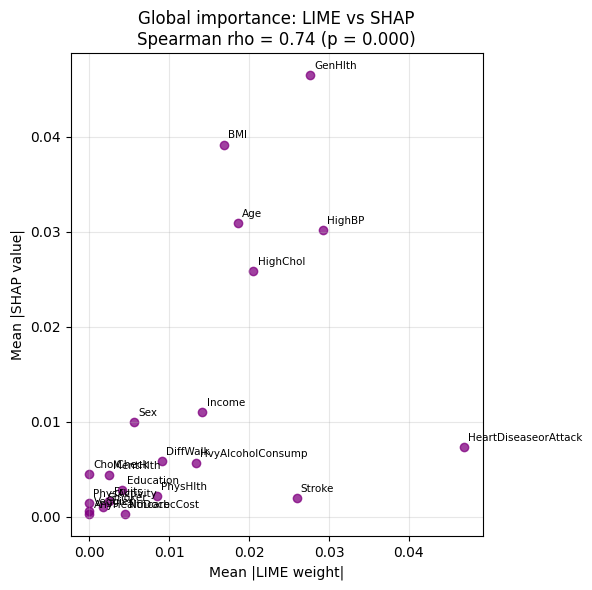

Spearman rank correlation: rho = 0.739, p = 0.0001


In [31]:
lime_global = lime_global_df.set_index("feature")["mean |LIME weight|"]
shap_global = shap_global_df.set_index("feature")["mean |SHAP|"]
aligned_importance = pd.DataFrame({
    "LIME": lime_global,
    "SHAP": shap_global,
}).dropna()

rho, p_value = spearmanr(aligned_importance["LIME"], aligned_importance["SHAP"])
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(aligned_importance["LIME"], aligned_importance["SHAP"], color="purple", alpha=0.75)
for feature, row in aligned_importance.iterrows():
    ax.annotate(
        feature,
        (row["LIME"], row["SHAP"]),
        fontsize=7.5,
        ha="left",
        va="bottom",
        xytext=(3, 3),
        textcoords="offset points",
    )
ax.set_xlabel("Mean |LIME weight|")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title(f"Global importance: LIME vs SHAP\nSpearman rho = {rho:.2f} (p = {p_value:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Spearman rank correlation: rho = {rho:.3f}, p = {p_value:.4f}")